#Introduction to Python Imaging Library(PIL)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2.1 Exercise - 1:

1. Read and display the image.

• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.

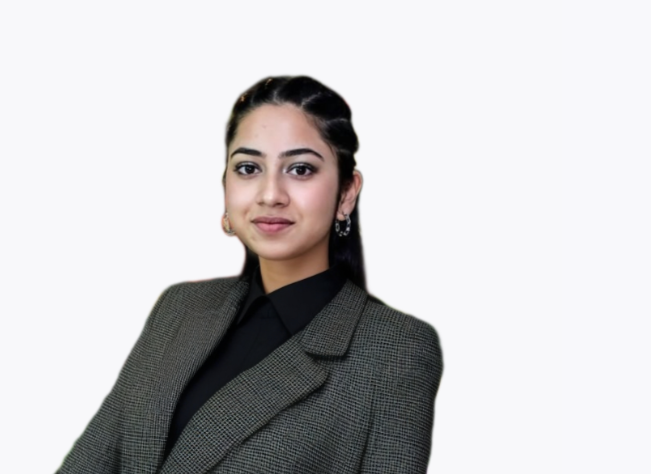

In [3]:
from PIL import Image
image_colored = Image.open("/content/drive/MyDrive/AI/Screenshot 2025-01-07 161430.png")
display(image_colored)

2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

shape of the image array: (474, 651, 4)


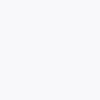

In [4]:
import numpy as np
image_array_colored = np.array(image_colored)
print("shape of the image array:", image_array_colored.shape)
left = 0
upper = 0
lower = 100
right = 100
cropped_image = image_colored.crop((left, upper, right, lower))
display(cropped_image)

3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

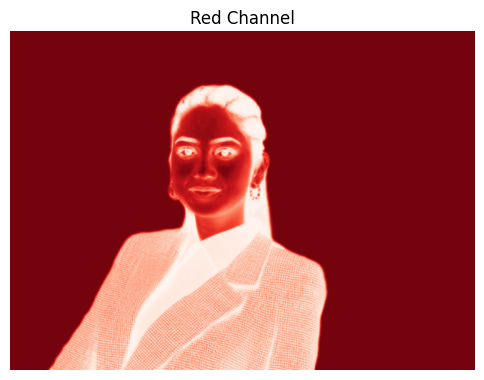

In [5]:
import matplotlib.pyplot as plt
R = image_array_colored[:, :, 0]
plt.figure(figsize=(6, 6))
plt.imshow(R, cmap='Reds', vmin=0, vmax=255)
plt.title("Red Channel")
plt.axis('off')
plt.show()

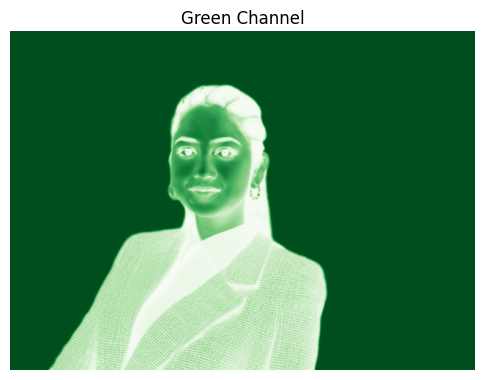

In [6]:

G = image_array_colored[:, :, 1]
plt.figure(figsize=(6, 6))
plt.imshow(G, cmap='Greens', vmin=0, vmax=255)
plt.title("Green Channel")
plt.axis('off')
plt.show()

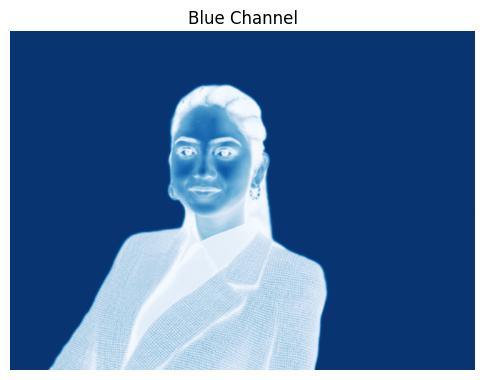

In [7]:

B = image_array_colored[:, :, 2]
plt.figure(figsize=(6, 6))
plt.imshow(B, cmap='Blues', vmin=0, vmax=255)
plt.title("Blue Channel")
plt.axis('off')
plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

Modified Image (top-left 100x100 pixels set to 210):


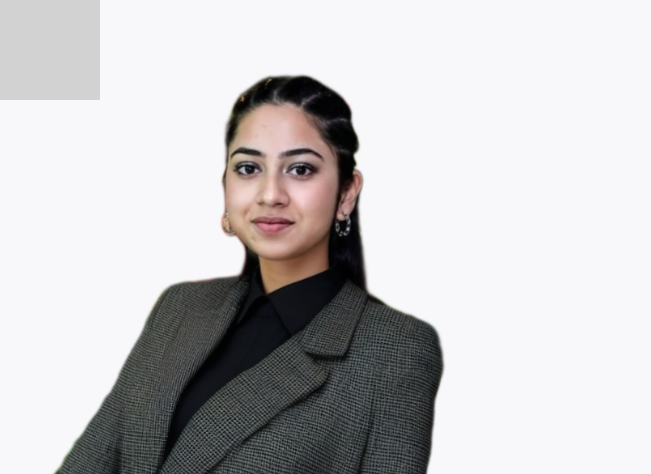

In [8]:
modified_image_array = np.copy(image_array_colored)
modified_image_array[0:100, 0:100, :3] = 210
modified_pil_image = Image.fromarray(modified_image_array)
print("Modified Image (top-left 100x100 pixels set to 210):")
display(modified_pil_image)

##2.2 Exercise - 2:

Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

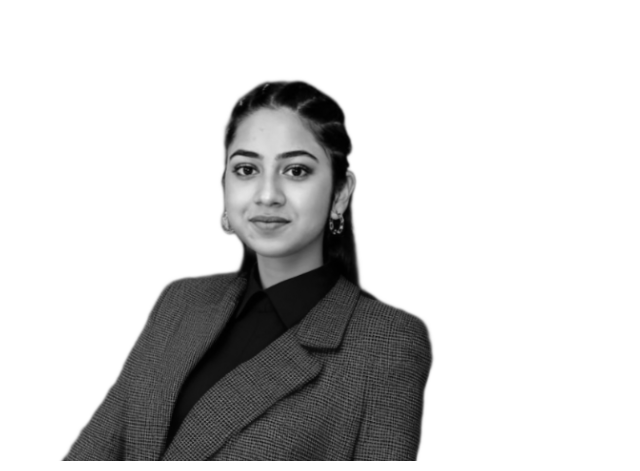

In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("/content/drive/MyDrive/AI/Screenshot 2025-01-07 161430.png")

image_grayscale = image.convert("L")
image_array_grayscale = np.array(image_grayscale)

plt.figure(figsize=(8, 8))
plt.imshow(image_array_grayscale, cmap='gray')
plt.axis('off')
plt.show()

2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.

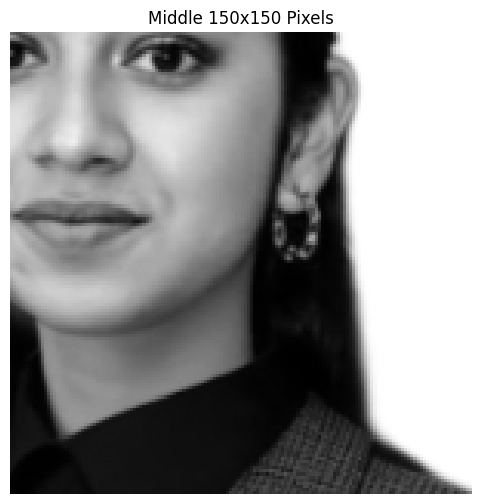

In [14]:
height, width = image_array_grayscale.shape

section_size = 150

start_row = max(0, (height // 2) - (section_size // 2))
start_col = max(0, (width // 2) - (section_size // 2))

end_row = min(height, start_row + section_size)
end_col = min(width, start_col + section_size)
middle_section = image_array_grayscale[start_row:end_row, start_col:end_col]

plt.figure(figsize=(6,6))
plt.imshow(middle_section, cmap='gray')
plt.title(f"Middle {section_size}x{section_size} Pixels")
plt.axis('off')
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.

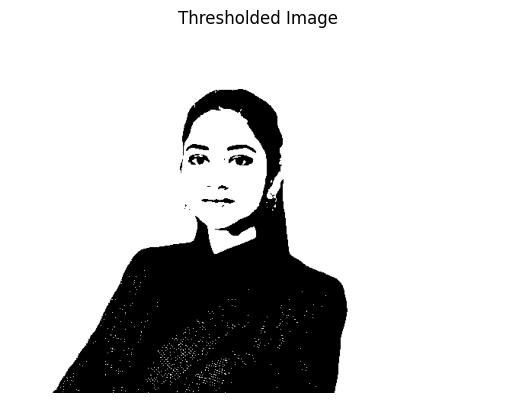

In [15]:

threshold = 100
binary_image = np.where(image_array_grayscale < threshold, 0, 255)
plt.imshow(binary_image, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.

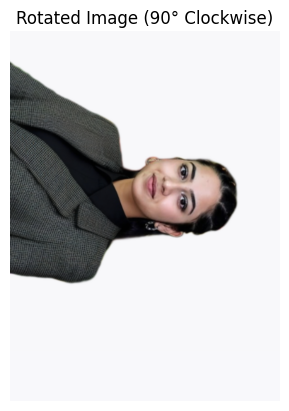

In [16]:
rotated_image = image.rotate(-90, expand=True)
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis('off')
plt.show()

5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

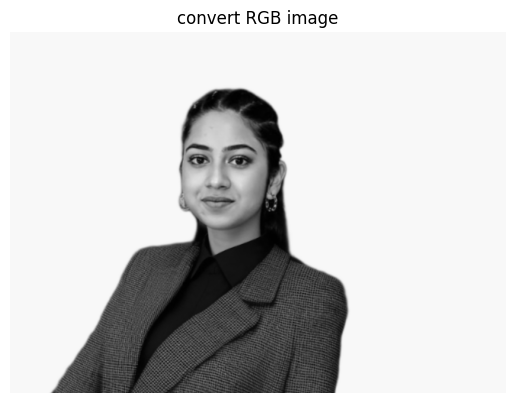

In [18]:
rgb_image = np.stack((image_array_grayscale,)*3, axis=-1)
plt.imshow(rgb_image)
plt.title("convert RGB image")
plt.axis('off')
plt.show()

#3 Image Compression and Decompression using PCA.

1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.

In [20]:
image_array = image_array_grayscale

mean = np.mean(image_array, axis=0)
centered_data = image_array - mean

cov_matrix = np.cov(centered_data, rowvar=False)

print("Mean shape:", mean.shape)
print("Centered data shape:", centered_data.shape)
print("Covariance matrix shape:", cov_matrix.shape)

Mean shape: (651,)
Centered data shape: (474, 651)
Covariance matrix shape: (651, 651)


2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.

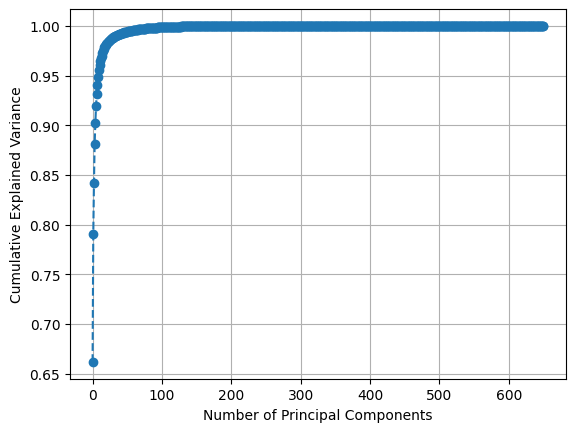

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

explained_variance = eigenvalues / np.sum(eigenvalues)
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

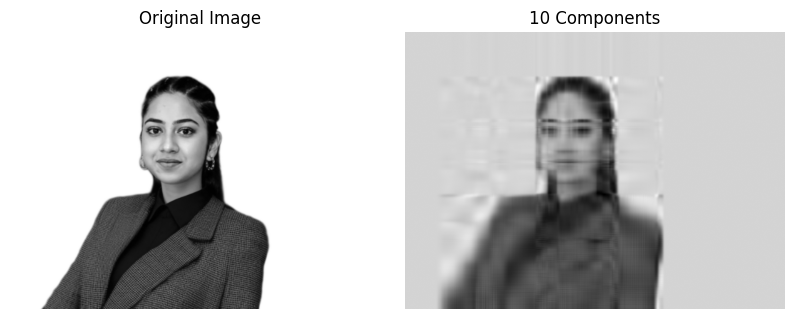

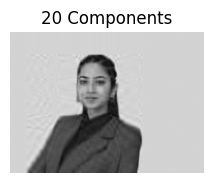

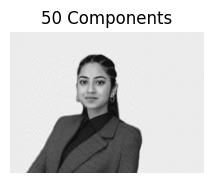

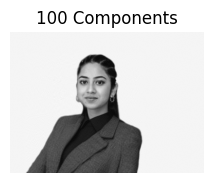

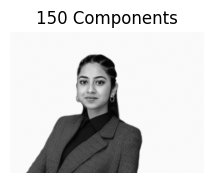

In [22]:
k_values = [10, 20, 50, 100, 150]
plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(image_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")
for idx, k in enumerate(k_values, start=2):
    components = eigenvectors[:, :k]
    compressed_data = np.dot(centered_data, components)
    reconstructed_data = np.dot(compressed_data, components.T) + mean
    plt.subplot(2,3,idx)
    plt.imshow(reconstructed_data, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")
    plt.tight_layout()
    plt.show()